# Q3: Does adoption differ by specialty, and can we trust the pattern?

**The question (business question 3):** can specialty and demographic segments be classified as high or low adopters of Zilretta, and does adoption vary by specialty?

**The answer, in one line:** adoption varies a lot by specialty. Eight specialties sit clearly above or below the market-wide share, the ranking is stable across the two halves of the data, and every headline conclusion survives removing the known data problems.

**What this notebook does.** It fits a statistical model to the visit counts, reports each specialty's *adjusted share* with honest intervals, checks the pattern holds over time, and repeats everything without the three known data problems (decisions DL-39, DL-46, DL-47). Methods and pass/fail rules were written into `docs/phase4_modeling_plan.md` before the real runs.

**How to read the numbers.** *Share* means Zilretta's visits as a fraction of visits for Zilretta, generic corticosteroid injections and NSAIDs together. *Adjusted share* is a specialty's share after allowing for differences in month, age and gender mix.

> This notebook runs the full bootstraps and the sensitivity re-runs, so it takes about 15 minutes.

In [1]:
import sys
import time
import warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

from oa_market_intelligence.analysis.adoption import (
    adjusted_shares, bootstrap_adjusted_shares, build_design, combine_intervals, deviance_shares,
    fit_binomial, group_specialties, load_adoption_data, split_half_stability)
from oa_market_intelligence.analysis.sensitivity import run_sensitivity

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 150)

engine = create_engine("sqlite:///../data/published/warehouse.db")
raw = load_adoption_data(engine)
df = group_specialties(raw)
print(f"{len(raw)} rows (month × specialty × age band × gender); specialties kept separate: {df['specialty'].nunique() - 1}, plus one grouped 'rare' set")
print(sorted(df["specialty"].unique()))

21636 rows (month × specialty × age band × gender); specialties kept separate: 11, plus one grouped 'rare' set
['ANESTHESIOLOGY', 'FAMILY PRACTICE', 'INTERNAL MEDICINE', 'NURSE PRACTITIONER', 'ORTHOPEDIC SURGERY', 'OSTEOPATHIC MEDICINE', 'PAIN MEDICINE', 'PHYSICAL MEDICINE & REHAB', 'PHYSICIAN ASSISTANT', 'RARE (grouped)', 'RHEUMATOLOGY', 'SPORTS MEDICINE']


## 1. The model, in plain words

For every month, specialty, age band and gender there is a count of Zilretta visits out of all category visits. The model treats each as a number of "successes" out of a number of "tries", and asks how the chance of a Zilretta visit depends on:

- the **month** (one setting per month, which absorbs the market-wide level and its ups and downs),
- the **specialty**, the **age band** and the **gender**.

Because it uses the counts as they are, a small segment counts for less than a big one, instead of being thrown away or counted equally.

**Adjusted share.** To compare specialties fairly we ask: *what would Zilretta's share be if every visit in the data had been in this specialty, keeping each visit's month, age and gender?* That removes differences in age and gender mix from the comparison.

First, a gate: the model must reproduce the observed totals exactly (a property of this kind of model, which makes it a good check that nothing is broken).

In [2]:
design = build_design(df)
fit = fit_binomial(design, df)
fitted = 1 / (1 + np.exp(-(design.X @ fit.beta))) * df["category"].to_numpy()
print("converged:", fit.converged, "| iterations:", fit.iterations, "| dispersion (1.0 would be a plain binomial):", round(fit.pearson_chi2 / fit.df_resid, 2))
print(f"total Zilretta visits: observed {int(df['zilretta'].sum())}, fitted {fitted.sum():.1f}")
for col in ("specialty", "age_band", "gender"):
    gap = (df.assign(f=fitted).groupby(col)["f"].sum() - df.groupby(col)["zilretta"].sum()).abs().max()
    print(f"  largest gap between fitted and observed visits by {col}: {gap:.6f}")

converged: True | iterations: 7 | dispersion (1.0 would be a plain binomial): 1.7
total Zilretta visits: observed 135119, fitted 135119.0
  largest gap between fitted and observed visits by specialty: 0.000000
  largest gap between fitted and observed visits by age_band: 0.000000
  largest gap between fitted and observed visits by gender: 0.000000


## 2. How much does each factor matter?

The next table drops one factor at a time and measures how much worse the model fits. The numbers are shares of the explainable variation. They can overlap, so they need not add to exactly 100%.

The p-value for specialty is shown, but **it should not be quoted to stakeholders**: the data varies more than a plain binomial allows (dispersion above 1), visits within a segment are not independent, and a p-value that small says only "not zero". The effect sizes and the stability checks below are the real evidence.

In [3]:
ds = deviance_shares(df)
print(pd.DataFrame({t: {"share of explainable variation": round(ds[t]["share"], 3)} for t in ("specialty", "age_band", "gender")}).T.to_string())
print(f"specialty F = {ds['specialty_F']:.0f}, p = {ds['specialty_p']:.2g}, dispersion = {ds['dispersion']:.2f}")

           share of explainable variation
specialty                           0.508
age_band                            0.505
gender                              0.003
specialty F = 672, p = 0, dispersion = 1.70


**What this shows.** Specialty and age band each carry about half of the explainable variation. Gender carries almost none (0.3%).

## 3. Adjusted share by specialty, with honest intervals

Two bootstraps of 1,000 refits each: one resamples months, the other resamples whole segments. The wider interval is reported for every specialty, because visits are not independent. (This takes a few minutes.)

In [4]:
t0 = time.time()
by_month = bootstrap_adjusted_shares(df, by="month", n_boot=1000, seed=0)
by_segment = bootstrap_adjusted_shares(df, by="segment", n_boot=1000, seed=0)
both = combine_intervals(by_month["table"], by_segment["table"])
width_ratio = (by_segment["table"]["high"] - by_segment["table"]["low"]) / (by_month["table"]["high"] - by_month["table"]["low"])
print(f"two bootstraps in {time.time()-t0:.0f}s; refits that did not converge: months {by_month['n_failed']}, segments {by_segment['n_failed']}")
print(f"the segment bootstrap interval is {width_ratio.min():.1f} to {width_ratio.max():.1f} times (median {width_ratio.median():.1f}) as wide as the month bootstrap interval")
overall = df["zilretta"].sum() / df["category"].sum()
volume = (df.groupby("specialty")["category"].sum() / df["category"].sum() * 100).round(1)
table = (both * 100).round(2).join(volume.rename("share of visits (%)")).sort_values("estimate", ascending=False)
table["position"] = np.where(table["low"] / 100 > overall, "clearly above", np.where(table["high"] / 100 < overall, "clearly below", "not clearly different"))
print(f"\noverall share {overall*100:.2f}%")
print(table.rename(columns={"estimate": "adjusted share (%)", "low": "90% low", "high": "90% high"}).to_string())

two bootstraps in 154s; refits that did not converge: months 0, segments 2
the segment bootstrap interval is 1.0 to 2.7 times (median 1.9) as wide as the month bootstrap interval

overall share 2.49%
                           adjusted share (%)  90% low  90% high  share of visits (%)               position
PHYSICAL MEDICINE & REHAB                5.34     4.73      5.93                  1.8          clearly above
SPORTS MEDICINE                          4.52     4.03      5.04                  2.8          clearly above
NURSE PRACTITIONER                       3.18     2.92      3.46                  8.0          clearly above
ANESTHESIOLOGY                           3.08     2.48      3.87                  0.8  not clearly different
OSTEOPATHIC MEDICINE                     2.89     2.64      3.13                  7.6          clearly above
PHYSICIAN ASSISTANT                      2.65     2.44      2.86                 28.6  not clearly different
PAIN MEDICINE                        

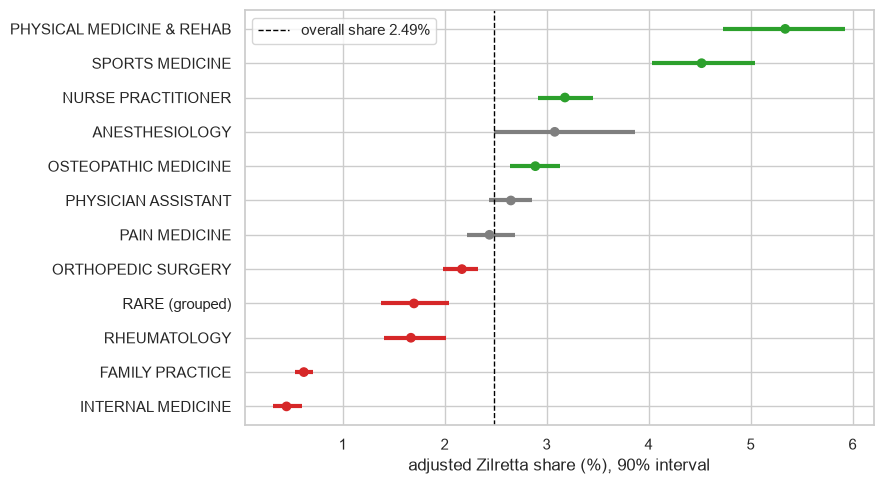

In [5]:
plot = table.sort_values("estimate")
colors = plot["position"].map({"clearly above": "#2ca02c", "clearly below": "#d62728", "not clearly different": "#7f7f7f"})
fig, ax = plt.subplots(figsize=(9, 5))
ax.hlines(range(len(plot)), plot["low"], plot["high"], color=colors, lw=3)
ax.scatter(plot["estimate"], range(len(plot)), color=colors, zorder=3)
ax.axvline(overall * 100, color="black", ls="--", lw=1, label=f"overall share {overall*100:.2f}%")
ax.set_yticks(range(len(plot))); ax.set_yticklabels(plot.index)
ax.set_xlabel("adjusted Zilretta share (%), 90% interval"); ax.legend()
plt.tight_layout(); plt.show()

**What this shows.** Physical Medicine & Rehab, Sports Medicine, Nurse Practitioner and Osteopathic Medicine are clearly above the overall share. Orthopedic Surgery (the largest specialty, 43% of visits), Rheumatology, Family Practice and Internal Medicine are clearly below it. Physician Assistant, Pain Medicine and Anesthesiology are not clearly different. (The grouped set of small "rare" specialties also shows as clearly below, but it mixes many different specialties, so it is not interpreted.) The adjusted shares are almost the same as the raw observed shares, so the gaps are not an artefact of differences in age and gender mix.

Using only the month bootstrap would have roughly halved the stated uncertainty, which is why the wider interval is reported.

## 4. Is the pattern stable over time?

A recommendation like "focus on specialty X" is only reliable if the ranking holds up over time. The model is fitted separately to the first 36 and the last 36 months, and the adjusted shares are compared.

rank agreement between the two halves: 0.78 (90% interval 0.75 to 0.93)
correlation on the log-odds scale: 0.89; share of specialties on the same side of their half's overall share: 82%
overall share: first half 2.66%, second half 2.31%
                           first_half  second_half side, first half side, second half flipped
SPORTS MEDICINE                  4.97         4.04            above             above        
ANESTHESIOLOGY                   4.04         1.95            above             below    FLIP
PHYSICAL MEDICINE & REHAB        3.99         6.66            above             above        
NURSE PRACTITIONER               3.66         2.75            above             above        
OSTEOPATHIC MEDICINE             3.16         2.61            above             above        
PHYSICIAN ASSISTANT              2.96         2.35            above             above        
PAIN MEDICINE                    2.81         2.03            above             below    FLIP
ORTHOPEDIC 

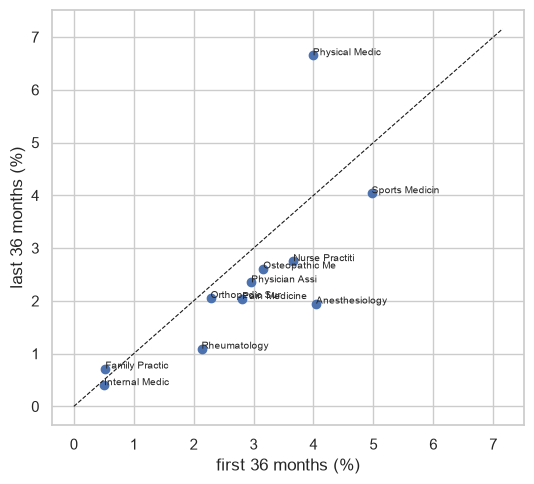

In [6]:
st = split_half_stability(df, n_boot=200, seed=0)
print(f"rank agreement between the two halves: {st['spearman']:.2f} (90% interval {st['spearman_low']:.2f} to {st['spearman_high']:.2f})")
print(f"correlation on the log-odds scale: {st['pearson_logit']:.2f}; share of specialties on the same side of their half's overall share: {st['same_side_fraction']:.0%}")
halves = [sorted(df["month_id"].unique())[:36], sorted(df["month_id"].unique())[36:]]
overall_halves = [df[df["month_id"].isin(h)]["zilretta"].sum() / df[df["month_id"].isin(h)]["category"].sum() for h in halves]
tab = (st["table"] * 100).round(2)
tab["side, first half"] = np.where(st["table"]["first_half"] > overall_halves[0], "above", "below")
tab["side, second half"] = np.where(st["table"]["second_half"] > overall_halves[1], "above", "below")
tab["flipped"] = np.where(tab["side, first half"] != tab["side, second half"], "FLIP", "")
print(f"overall share: first half {overall_halves[0]*100:.2f}%, second half {overall_halves[1]*100:.2f}%")
print(tab.sort_values("first_half", ascending=False).to_string())
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(st["table"]["first_half"] * 100, st["table"]["second_half"] * 100)
for name, row in st["table"].iterrows():
    ax.annotate(name.title()[:14], (row["first_half"] * 100, row["second_half"] * 100), fontsize=7)
lim = [0, max(st["table"].max()) * 100 + 0.5]
ax.plot(lim, lim, "k--", lw=0.8); ax.set_xlabel("first 36 months (%)"); ax.set_ylabel("last 36 months (%)")
plt.tight_layout(); plt.show()

**What this shows.** The ranking agrees well (rank correlation about 0.78). The top (Physical Medicine & Rehab, Sports Medicine) and bottom (Family Practice, Internal Medicine) are the same in both halves, and Orthopedic Surgery and Rheumatology are below the overall share in both. **Anesthesiology and Pain Medicine flip** from above to below, so they should not be featured. Most specialties' shares fell between the halves, consistent with notebook 06. Physical Medicine & Rehab is the exception: it rose.

## 5. Do the conclusions survive the known data problems?

The whole Q1 and Q3 analysis is re-run on the baseline and with each of three exclusions, in turn: the **PEDIATRICS** specialty (a suspected mis-coded prescriber from October 2024), the **COVID months** (March to May 2020), and the **March to July 2024 volume dip**. The pass/fail rules were fixed before the run (plan, Step 5). A conclusion is *robust* only if its rule holds in all four runs. (About 7 minutes.)

| Rule | What has to hold |
|---|---|
| T1 | Zilretta's share has a trend break in early 2022 (significant, and inside the baseline 90% interval) |
| D1 | The decline is within specialties: the rate effect is negative and at least twice the mix effect |
| A1 | Adoption varies by specialty: specialty carries at least 25% of explainable variation, p < 0.01 |
| A2 | Every clearly above or below specialty stays so, with its interval still excluding the overall share |
| A3 | The split-half rank correlation is at least 0.6 |

In [7]:
t0 = time.time()
res = run_sensitivity(raw, n_null=1000, n_boot=300, n_boot_stability=100, seed=0)
print(f"sensitivity run took {time.time()-t0:.0f}s")
rows = []
for key, v in res["verdicts"].items():
    rows.append({"rule": key, "verdict": v["label"], "failed in": ", ".join(v["failed"]) or "-"})
print(pd.DataFrame(rows).to_string(index=False))
print()
for name, run in res["runs"].items():
    tr, dec, ad = run["trend"], run["decomposition"], run["adoption"]
    print(f"{name:16s} months {run['n_months']:2d} | break {tr['break_months']} p={tr['p_first']:.3f} | rate/|mix| first→last {abs(dec['first_to_last']['rate'])/abs(dec['first_to_last']['mix']):.1f} | specialty share {ad['specialty_share']:.3f} | split-half rank correlation {ad['spearman']:.2f}")

sensitivity run took 311s
rule verdict failed in
  T1  robust         -
  D1  robust         -
  A1  robust         -
  A3  robust         -
  A2  robust         -

baseline         months 72 | break [202203] p=0.001 | rate/|mix| first→last 4.9 | specialty share 0.508 | split-half rank correlation 0.78
PEDIATRICS       months 72 | break [202201] p=0.001 | rate/|mix| first→last 6.2 | specialty share 0.518 | split-half rank correlation 0.78
COVID months     months 69 | break [202201] p=0.001 | rate/|mix| first→last 4.0 | specialty share 0.505 | split-half rank correlation 0.85
2024 dip months  months 67 | break [202203] p=0.001 | rate/|mix| first→last 4.9 | specialty share 0.512 | split-half rank correlation 0.88


In [8]:
by_run = pd.DataFrame({name: run["adoption"]["table"]["estimate"] * 100 for name, run in res["runs"].items()}).round(2)
print("adjusted share (%) by specialty in each run:")
print(by_run.sort_values("baseline", ascending=False).to_string())

adjusted share (%) by specialty in each run:
                           baseline  PEDIATRICS  COVID months  2024 dip months
PHYSICAL MEDICINE & REHAB      5.34        5.34          5.39             5.17
SPORTS MEDICINE                4.52        4.51          4.50             4.57
NURSE PRACTITIONER             3.18        3.19          3.18             3.27
ANESTHESIOLOGY                 3.08        3.08          3.07             3.16
OSTEOPATHIC MEDICINE           2.89        2.89          2.89             2.94
PHYSICIAN ASSISTANT            2.65        2.65          2.63             2.68
PAIN MEDICINE                  2.44        2.44          2.40             2.46
ORTHOPEDIC SURGERY             2.17        2.16          2.17             2.19
RARE (grouped)                 1.70        1.08          1.72             1.75
RHEUMATOLOGY                   1.67        1.67          1.63             1.71
FAMILY PRACTICE                0.62        0.62          0.62             0.64
INTERNA

**What this shows.** All five rules hold in all four runs, so every headline conclusion is **robust** against these three data problems. Two refinements come out of the table: the PEDIATRICS anomaly inflates the grouped "other specialties" share (it drops once PEDIATRICS is removed) but changes none of the named specialties, and the net fall from the first year to the last year is smaller without the COVID months (April 2020 was unusually high), while the larger peak-to-latest fall is unaffected.

## What this means, and what it does not

**Supported:**
- Adoption differs strongly by specialty. Eight specialties are clearly above or below the market-wide share, and the ranking holds in both halves of the data and under all three robustness checks.
- The gaps are not explained by differences in age or gender mix.
- Specialty and age band carry about half of the explainable variation each; gender carries almost none.

**Not supported:**
- Anything about *why* a specialty is above or below. A specialty below the market-wide share is a **lead to investigate**, not proof of an opportunity: the gap may reflect patient mix, access or practice setting the data cannot see.
- The exact order in the middle of the table, and any statement about Anesthesiology or Pain Medicine.

**A limit on "robust".** The three exclusions are small perturbations (PEDIATRICS is about 0.03% of visits; COVID and the dip remove 3 and 5 of 72 months). Surviving them means the findings are not driven by *these* known problems, not that they survive every possible one.